## Simula a sucessão ecológica entre (grass, shrubs and forest)

Código adaptado do site:
https://towardsdatascience.com/markov-chain-analysis-and-simulation-using-python-4507cee0b06e


O Código usa Masked Arrays:

https://numpy.org/doc/stable/reference/maskedarray.generic.html

In [1]:
import numpy as np
import pandas as pd
from random import seed
from random import random
import matplotlib.pyplot as plt

In [2]:
P = np.array([[0.5, 0.45, 0.05],
              [0.1, 0.5, 0.4],
              [0.0, 0.1, 0.9]])
stateChangeHist= np.array([[0.0,  0.0,  0.0],
                          [0.0, 0.0,  0.0],
                          [0.0, 0.0,  0.0]])
state=np.array([[1.0, 0.0, 0.0]])
currentState=0
stateHist=state
dfStateHist=pd.DataFrame(state)
distr_hist = [[1,0,0]]
seed(4)

In [3]:
# Simulate from multinomial distribution
def simulate_multinomial(vmultinomial):
  r=np.random.uniform(0.0, 1.0)
  CS=np.cumsum(vmultinomial)
  CS=np.insert(CS,0,0)
  m=(np.where(CS<r))[0]
  nextState=m[len(m)-1]
  return nextState


for x in range(600):
  currentRow=np.ma.masked_values((P[currentState]), 0.0)
  nextState=simulate_multinomial(currentRow)
  # Keep track of state changes
  stateChangeHist[currentState,nextState]+=1
  # Keep track of the state vector itself
  state=np.array([[0,0,0]])
  state[0,nextState]=1.0
  # Keep track of state history
  stateHist=np.append(stateHist,state,axis=0)
  currentState=nextState
  # calculate the actual distribution over the 3 states so far
  totals=np.sum(stateHist,axis=0)
  gt=np.sum(totals)
  distrib=totals/gt
  distrib=np.reshape(distrib,(1,3))
  distr_hist=np.append(distr_hist,distrib,axis=0)

In [4]:
print(distrib)
P_hat=stateChangeHist/stateChangeHist.sum(axis=1)[:,None]
# Check estimated state transition probabilities based on history so far:
print(P_hat)
dfDistrHist = pd.DataFrame(distr_hist)

[[0.04492512 0.21297837 0.74209651]]
[[0.48148148 0.51851852 0.        ]
 [0.1015625  0.5078125  0.390625  ]
 [0.         0.11011236 0.88988764]]


In [5]:
dfDistrHist

,0,1,2
0,1.000000,0.000000,0.000000
1,1.000000,0.000000,0.000000
2,1.000000,0.000000,0.000000
3,0.750000,0.250000,0.000000
4,0.600000,0.400000,0.000000
...,...,...,...
596,0.045226,0.214405,0.740369
597,0.045151,0.214047,0.740803
598,0.045075,0.213689,0.741235
599,0.045000,0.213333,0.741667


In [6]:
dfDistrHist2 = dfDistrHist.rename(columns={0: "grass", 1: "shrubs", 2: "forest"})

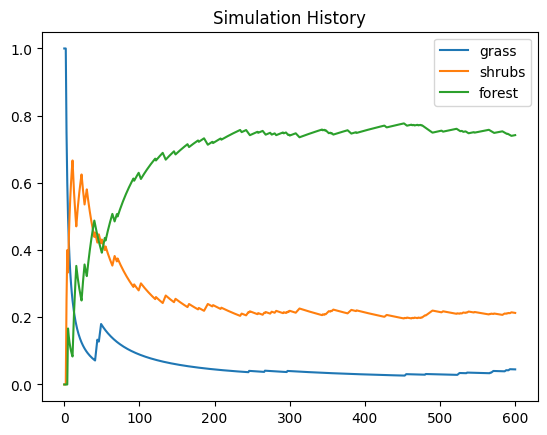

In [7]:
# Plot the distribution as the simulation progresses over time
dfDistrHist2.plot(title="Simulation History")
plt.show()

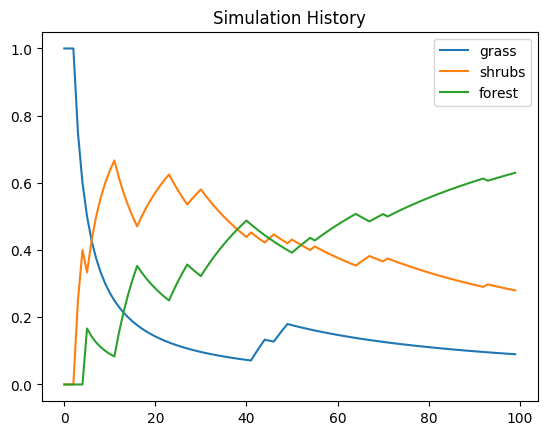

In [8]:
# Plot the distribution as the simulation progresses over time
dfDistrHist2[0:100].plot(title="Simulation History")
plt.show()